In [48]:
import pandas as pd
import numpy as np
import random
np.random.seed(42)
random.seed(42)

n = 500

data = pd.DataFrame({
    "age": np.random.normal(loc=60, scale=10, size=n).astype(int),
    "sex": np.random.choice(["M", "F"], size=n),
    "has_diabetes": np.random.choice([0, 1], p=[0.7, 0.3], size=n),
    "systolic_bp": np.random.normal(loc=140, scale=20, size=n),
})

print(data.head())
print(data.describe(include="all"))

   age sex  has_diabetes  systolic_bp
0   64   F             0   160.605669
1   58   F             0   144.775783
2   66   F             0   134.819157
3   75   M             0   136.073003
4   57   F             0   138.567975
               age  sex  has_diabetes  systolic_bp
count   500.000000  500    500.000000   500.000000
unique         NaN    2           NaN          NaN
top            NaN    M           NaN          NaN
freq           NaN  260           NaN          NaN
mean     59.540000  NaN      0.316000   141.391120
std       9.831262  NaN      0.465379    20.268494
min      27.000000  NaN      0.000000    82.074892
25%      52.750000  NaN      0.000000   127.100839
50%      60.000000  NaN      0.000000   141.136630
75%      66.000000  NaN      1.000000   154.577644
max      98.000000  NaN      1.000000   192.033662


In [49]:
from ctgan import CTGAN

discrete_cols = ["sex", "has_diabetes"]
ctgan = CTGAN(epochs=10)
ctgan.fit(data, discrete_cols)
synthetic = ctgan.sample(500)
print(synthetic.head())
print(synthetic.describe(include="all"))


   age sex  has_diabetes  systolic_bp
0   71   F             0   110.365467
1   59   M             0   206.208584
2   41   M             0   182.781076
3   57   M             0   118.573864
4   38   M             1   179.814411
               age  sex  has_diabetes  systolic_bp
count   500.000000  500    500.000000   500.000000
unique         NaN    2           NaN          NaN
top            NaN    M           NaN          NaN
freq           NaN  280           NaN          NaN
mean     66.188000  NaN      0.418000   161.802413
std      12.880857  NaN      0.493724    25.653863
min      30.000000  NaN      0.000000    83.921946
25%      57.000000  NaN      0.000000   143.463961
50%      67.000000  NaN      0.000000   164.156360
75%      75.000000  NaN      1.000000   180.669502
max      98.000000  NaN      1.000000   214.080921


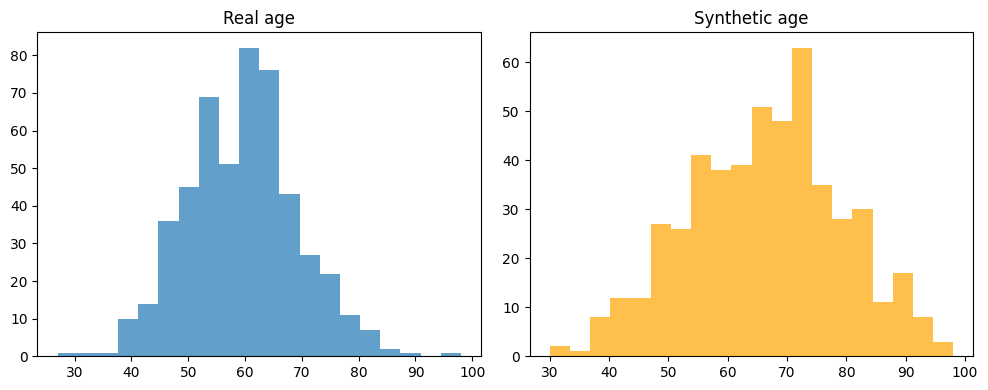

In [50]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(data["age"], bins=20, alpha=0.7, label="real")
axes[0].set_title("Real age")
axes[1].hist(synthetic["age"], bins=20, alpha=0.7, color="orange", label="synthetic")
axes[1].set_title("Synthetic age")
plt.tight_layout()
plt.show()

In [51]:
print("Real diabetes rate:", data["has_diabetes"].mean())
print("Synthetic diabetes rate:", synthetic["has_diabetes"].mean())

Real diabetes rate: 0.316
Synthetic diabetes rate: 0.418


# SDV with Adult dataset

In [52]:
import openml

from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer

adult_dataset = openml.datasets.get_dataset(1590)

X, y, categorical_indicator, attribute_names = adult_dataset.get_data(
    target=adult_dataset.default_target_attribute,
    dataset_format="dataframe"
)

print("features:")
print(X.head())

print("target:")
print(y.head())

features:
   age  workclass    fnlwgt     education  education-num      marital-status  \
0   25    Private  226802.0          11th              7       Never-married   
1   38    Private   89814.0       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951.0    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323.0  Some-college             10  Married-civ-spouse   
4   18        NaN  103497.0  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male           0.0           0.0   
1    Farming-fishing      Husband  White    Male           0.0           0.0   
2    Protective-serv      Husband  White    Male           0.0           0.0   
3  Machine-op-inspct      Husband  Black    Male        7688.0           0.0   
4                NaN    Own-child  White  Female           0.0           0.0   

   hours-per-week native-cou

In [53]:
df = X.copy()
# add column income to df
df['income'] = y
print("\nDataFrame info:")
print(df.info())

missing_counts = df.isna().sum()
cols_with_missing = missing_counts[missing_counts > 0].index.tolist()

print("cols with missing values: ", cols_with_missing)

# select categorical columns to keep
categorical_cols = df.select_dtypes(include=['category']).columns.tolist()
cols_with_missing = [
    col for col in cols_with_missing
    if col in categorical_cols
]
print("Categorical columns with missing values:", cols_with_missing)

# fill with "Unknown"
for col in cols_with_missing:
    df[col] = df[col].cat.add_categories(['Unknown'])
    df[col] = df[col].fillna('Unknown')

print("\nMissing values after filling:")
print(df[cols_with_missing].isna().sum())

for col in categorical_cols:
    df[col] = df[col].astype(str)


DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  uint8   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  float64 
 3   education       48842 non-null  category
 4   education-num   48842 non-null  uint8   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  float64 
 11  capital-loss    48842 non-null  float64 
 12  hours-per-week  48842 non-null  uint8   
 13  native-country  47985 non-null  category
 14  income          48842 non-null  category
dtypes: category(9), float64(3), uint8(3)
memory usage: 1.7 MB
None
cols with missing values

In [54]:
metadata = Metadata.detect_from_dataframe(df)
metadata.save_to_json('metadata.json')
print(metadata.to_dict())

{'tables': {'table': {'columns': {'age': {'sdtype': 'numerical'}, 'workclass': {'sdtype': 'categorical'}, 'fnlwgt': {'sdtype': 'numerical'}, 'education': {'sdtype': 'categorical'}, 'education-num': {'sdtype': 'numerical'}, 'marital-status': {'sdtype': 'categorical'}, 'occupation': {'sdtype': 'categorical'}, 'relationship': {'sdtype': 'categorical'}, 'race': {'sdtype': 'categorical'}, 'sex': {'sdtype': 'categorical'}, 'capital-gain': {'sdtype': 'numerical'}, 'capital-loss': {'sdtype': 'numerical'}, 'hours-per-week': {'sdtype': 'numerical'}, 'native-country': {'sdtype': 'categorical'}, 'income': {'sdtype': 'categorical'}}}}, 'relationships': [], 'METADATA_SPEC_VERSION': 'V1'}


In [55]:
df_train_sdg = df.sample(frac=2/3, random_state=42)

# ctgan
synthesizer = CTGANSynthesizer(
    metadata=metadata,
    enforce_rounding=True,
    epochs=300,
    verbose=True
)

synthesizer.fit(df_train_sdg)

Gen. (-0.33) | Discrim. (0.19):  27%|██▋       | 82/300 [13:25<35:42,  9.83s/it]   


KeyboardInterrupt: 

In [ ]:
# sample
num_synthetic = len(df)
synthetic_df = synthesizer.sample(num_rows=num_synthetic)
print("\nSynthetic data:")
print(synthetic_df.head())
print("\nSynthetic data info():")
print(synthetic_df.info())

In [ ]:
print("\nREAL:")
print(df['age'].describe())

print("\nSYNTHETIC:")
print(synthetic_df['age'].describe())

In [ ]:
print("\nREAL:")
print(df['sex'].value_counts(normalize=True))

print("\nSYNTHETIC:")
print(synthetic_df['sex'].value_counts(normalize=True))

In [ ]:
print("\nREAL:")
print(df['income'].value_counts(normalize=True))

print("\nSYNTHETIC:")
print(synthetic_df['income'].value_counts(normalize=True))

In [ ]:
from sklearn.model_selection import train_test_split

target_col = 'income'

X_real = df.drop(columns=[target_col])
y_real = (df[target_col] == '>50K').astype(int)

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real, test_size=0.3, random_state=42, stratify=y_real
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

def make_model(X):
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X.select_dtypes(include=['number']).columns.tolist()
    preprocess = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
            ('num', 'passthrough', num_cols)
        ]
    )
    return Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('model', RandomForestClassifier(random_state=42))
        ]
    )

### Utility

In [ ]:

from sklearn.metrics import roc_auc_score, precision_score, recall_score

def run_utility_metrics(model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    auroc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    return auroc, precision, recall

model_real = make_model(X_train_real)
model_real.fit(X_train_real, y_train_real)

auroc_real, precision_real, recall_real = run_utility_metrics(model_real, X_test_real, y_test_real)

print("AUROC:", auroc_real)
print("Precision:", precision_real)
print("Recall:", recall_real)

In [ ]:
X_synth = synthetic_df.drop(columns=[target_col])
y_synth = (synthetic_df[target_col] == '>50K').astype(int)

model_synth = make_model(X_synth)
model_synth.fit(X_synth, y_synth)

auroc_synth, precision_synth, recall_synth = run_utility_metrics(model_synth, X_test_real, y_test_real)

print("AUROC:", auroc_synth)
print("Precision:", precision_synth)
print("Recall:", recall_synth)

### Fairness

In [ ]:
y_pred_real = model_real.predict(X_test_real)
y_pred_synth = model_synth.predict(X_test_real)

from fairlearn.metrics import demographic_parity_difference

def dp_gap_real_synth(y_test, y_pred_real, y_pred_synth, sensitive_features):

    dp_real = demographic_parity_difference(
        y_true=y_test,
        y_pred=y_pred_real,
        sensitive_features=sensitive_features
    )

    dp_synth = demographic_parity_difference(
        y_true=y_test,
        y_pred=y_pred_synth,
        sensitive_features=sensitive_features
    )

    return dp_real, dp_synth

dp_real, dp_synth = dp_gap_real_synth(y_test_real, y_pred_real, y_pred_synth, df.loc[X_test_real.index, 'sex'])

print("Demographic parity difference (real):", dp_real)
print("Demographic parity difference (synthetic):", dp_synth)

In [ ]:
import numpy as np

def ftu_flip_rate(model, X, protected_col, protected_values=('Male', 'Female')):
    X0 = X.copy()
    X1 = X.copy()
    X0[protected_col] = protected_values[0]
    X1[protected_col] = protected_values[1]

    y0 = model.predict(X0)
    y1 = model.predict(X1)

    return float(np.mean(y0 != y1))

ftu_real = ftu_flip_rate(model_real, X_test_real, 'sex', ('Male', 'Female'))
ftu_synth = ftu_flip_rate(model_synth, X_test_real, 'sex', ('Male', 'Female'))

print("FTU flip rate (real):", ftu_real)
print("FTU flip rate (synthetic):", ftu_synth)

# Fairness with with AIF360

In [ ]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric, BinaryLabelDatasetMetric

In [ ]:
def compute_aif360_metrics(X_test, y_test, y_pred_real, y_pred_synth,
                           protected_attr, favorable_label, privileged_val):
    from sklearn.preprocessing import OneHotEncoder

    X_enc = X_test.copy()
    # encode protected attribute to 1=privileged, 0=unprivileged
    X_enc[protected_attr] = (X_enc[protected_attr] == privileged_val).astype(float)

    cat_cols = [c for c in X_enc.select_dtypes(include=['object', 'category']).columns
                if c != protected_attr]
    if cat_cols:
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded = ohe.fit_transform(X_enc[cat_cols])
        encoded_df = pd.DataFrame(encoded, index=X_enc.index,
                                  columns=ohe.get_feature_names_out(cat_cols))
        X_enc = X_enc.drop(columns=cat_cols).join(encoded_df)

    # Add label column
    X_enc['label'] = y_test.values if hasattr(y_test, 'values') else y_test

    dataset_true = BinaryLabelDataset(
        df=X_enc,
        label_names=['label'],
        protected_attribute_names=[protected_attr],
        favorable_label=favorable_label,
        unfavorable_label=1 - favorable_label,
    )

    privileged_groups = [{protected_attr: 1.0}]
    unprivileged_groups = [{protected_attr: 0.0}]

    def _get_metrics(dataset_true, y_pred, unprivileged_groups, privileged_groups):
        dataset_pred = dataset_true.copy()
        dataset_pred.labels = y_pred.reshape(-1, 1)

        cm = ClassificationMetric(dataset_true, dataset_pred,
                                  unprivileged_groups, privileged_groups)
        dm = BinaryLabelDatasetMetric(dataset_pred,
                                      unprivileged_groups, privileged_groups)

        return {
            "stat_par_diff": cm.statistical_parity_difference(),
            "disp_impact": cm.disparate_impact(),
            "eq_opp_diff": cm.equal_opportunity_difference(),
            "avg_odds_diff": cm.average_odds_difference(),
            "fpr_diff": cm.false_positive_rate_difference(),
            "fnr_diff": cm.false_negative_rate_difference(),
            "theil": cm.theil_index(),
            "consistency": float(dm.consistency()[0]),
        }

    return {
        "real": _get_metrics(dataset_true, y_pred_real, unprivileged_groups, privileged_groups),
        "synth": _get_metrics(dataset_true, y_pred_synth, unprivileged_groups, privileged_groups),
    }

In [ ]:
aif_adult = compute_aif360_metrics(
    X_test_real, y_test_real,
    y_pred_real, y_pred_synth,
    protected_attr='sex',
    favorable_label=1,
    privileged_val='Male',
)

print("AIF360 Fairness Metrics (Adult)")
for model_name, metrics in aif_adult.items():
    print(f"\n{model_name.upper()} model:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

### SDMetrics reports

In [ ]:
from sdmetrics.reports.single_table import QualityReport

sdv_metadata = metadata.to_dict()
sdmetrics_metadata = sdv_metadata['tables']['table']

quality_report = QualityReport()
quality_report.generate(
    real_data=df,
    synthetic_data=synthetic_df,
    metadata=sdmetrics_metadata
)
print("Overall Quality Score:", quality_report.get_score())
print(quality_report.get_details(property_name='Column Shapes'))

In [ ]:
from sdmetrics.reports.single_table import DiagnosticReport

diagnostic_report = DiagnosticReport()
diagnostic_report.generate(
    real_data=df,
    synthetic_data=synthetic_df,
    metadata=sdmetrics_metadata
)
print("Diagnostic Score:", diagnostic_report.get_score())
print("\nData Validity:")
print(diagnostic_report.get_details(property_name='Data Validity'))
print("\nData Structure:")
print(diagnostic_report.get_details(property_name='Data Structure'))

In [ ]:
from sdmetrics.single_table.privacy import DisclosureProtection

known_columns = ['age', 'sex', 'workclass', 'education']
sensitive_columns = ['income']
continuous_columns = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']

score = DisclosureProtection.compute(
    real_data=df,
    synthetic_data=synthetic_df,
    known_column_names=known_columns,
    sensitive_column_names=sensitive_columns,
    continuous_column_names=continuous_columns
)

print("DisclosureProtection score:", score)

In [ ]:
import numpy as np

from sdmetrics.reports.single_table import QualityReport, DiagnosticReport
from sdmetrics.single_table.privacy import DisclosureProtectionEstimate
from sdmetrics.single_table import (
    CategoryCoverage, ContingencySimilarity, CorrelationSimilarity,
    RangeCoverage, MissingValueSimilarity, StatisticSimilarity,
    BoundaryAdherence, TableStructure,
    KSComplement, TVComplement, CSTest,
    ContinuousKLDivergence, DiscreteKLDivergence,
    GMLogLikelihood,
    DCRBaselineProtection, DCROverfittingProtection,
    CategoricalCAP, CategoricalZeroCAP, CategoricalGeneralizedCAP,
    NewRowSynthesis,
    LogisticDetection, SVCDetection,
    BinaryLogisticRegression, BinaryDecisionTreeClassifier,
    BinaryAdaBoostClassifier, BinaryMLPClassifier,
    EqualizedOddsImprovement,
)
from sdmetrics.single_table.data_augmentation import (
    BinaryClassifierPrecisionEfficacy,
    BinaryClassifierRecallEfficacy,
)

BinaryLogisticRegression.MODEL_KWARGS = {
    **BinaryLogisticRegression.MODEL_KWARGS,
    'solver': 'liblinear', 'max_iter': 10000, 'n_jobs': 1,
}

BinaryMLPClassifier.MODEL_KWARGS = {
    **BinaryMLPClassifier.MODEL_KWARGS,
    'max_iter': 10000,
}

class _LogisticDetection(LogisticDetection):
    @staticmethod
    def _get_classifier():
        from sklearn.linear_model import LogisticRegression
        return LogisticRegression(solver='liblinear', max_iter=10000)

def _subset_metadata(metadata, cols):
    return {"columns": {c: metadata["columns"][c] for c in cols if c in metadata["columns"]}}

def _fix_unsigned_dtypes(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype.kind == 'u':
            df[col] = df[col].astype('int64')
    return df

def _align_categories(real_df, synth_df):
    mask = pd.Series(True, index=real_df.index)
    for col in real_df.select_dtypes(include=['object', 'category']).columns:
        synth_cats = set(synth_df[col].unique())
        mask &= real_df[col].isin(synth_cats)
    filtered = real_df.loc[mask].copy()
    return filtered

def run_sdmetrics(real_df, synth_df, metadata, target_col,
                  key_fields, sensitive_fields,
                  protected_col=None, positive_class_label=None,
                  minority_class_label=None, protected_value=None,
                  real_train_df=None, dcr_subsample=5000):
    real_df = _fix_unsigned_dtypes(real_df)
    synth_df = _fix_unsigned_dtypes(synth_df)
    results = {}

    if real_train_df is not None:
        _train_idx = real_df.index.intersection(real_train_df.index)
        real_train = real_df.loc[_train_idx].copy()
        real_valid = real_df.loc[real_df.index.difference(_train_idx)].copy()
    else:
        real_train = None
        real_valid = None

    num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = real_df.select_dtypes(exclude=[np.number]).columns.tolist()
    num_meta = _subset_metadata(metadata, num_cols)
    cat_meta = _subset_metadata(metadata, cat_cols)

    # reports
    q_report = QualityReport()
    q_report.generate(real_df, synth_df, metadata)
    results["QualityReport_overall"] = q_report.get_score()
    q_props = q_report.get_properties().set_index("Property")
    results["QualityReport_column_shapes"] = q_props.loc["Column Shapes", "Score"]
    results["QualityReport_column_pair_trends"] = q_props.loc["Column Pair Trends", "Score"]

    d_report = DiagnosticReport()
    d_report.generate(real_df, synth_df, metadata)
    results["DiagnosticReport_overall"] = d_report.get_score()

    # marginal distribution fidelity
    if num_cols:
        results["KSComplement"] = KSComplement.compute(
            real_data=real_df, synthetic_data=synth_df, metadata=metadata)
    if cat_cols:
        results["TVComplement"] = TVComplement.compute(
            real_data=real_df, synthetic_data=synth_df, metadata=metadata)
        results["CSTest"] = CSTest.compute(
            real_data=real_df, synthetic_data=synth_df, metadata=metadata)

    # joint distribution fidelity
    if len(num_cols) >= 2:
        results["CorrelationSimilarity"] = CorrelationSimilarity.compute(
            real_data=real_df[num_cols], synthetic_data=synth_df[num_cols], metadata=num_meta)
        results["ContinuousKLDivergence"] = ContinuousKLDivergence.compute(
            real_data=real_df[num_cols], synthetic_data=synth_df[num_cols], metadata=num_meta)

    if len(cat_cols) >= 2:
        cat2_meta = _subset_metadata(metadata, cat_cols[:2])
        results["ContingencySimilarity"] = ContingencySimilarity.compute(
            real_data=real_df[cat_cols[:2]], synthetic_data=synth_df[cat_cols[:2]], metadata=cat2_meta)
        results["DiscreteKLDivergence"] = DiscreteKLDivergence.compute(
            real_data=real_df[cat_cols[:2]], synthetic_data=synth_df[cat_cols[:2]], metadata=cat2_meta)

    # range, boundary, missing values
    if cat_cols:
        results["CategoryCoverage"] = CategoryCoverage.compute(
            real_data=real_df[cat_cols], synthetic_data=synth_df[cat_cols], metadata=cat_meta)
    if num_cols:
        results["RangeCoverage"] = RangeCoverage.compute(
            real_data=real_df[num_cols], synthetic_data=synth_df[num_cols], metadata=num_meta)
        results["BoundaryAdherence"] = BoundaryAdherence.compute(
            real_data=real_df[num_cols], synthetic_data=synth_df[num_cols], metadata=num_meta)
        results["StatisticSimilarity"] = StatisticSimilarity.compute(
            real_data=real_df[num_cols], synthetic_data=synth_df[num_cols], metadata=num_meta)
        results["MissingValueSimilarity"] = MissingValueSimilarity.compute(
            real_data=real_df[num_cols], synthetic_data=synth_df[num_cols], metadata=num_meta)
    results["TableStructure"] = TableStructure.compute(real_data=real_df, synthetic_data=synth_df)

    # synthetic plausibility under real distribution
    if num_cols:
        results["GMLogLikelihood"] = GMLogLikelihood.compute(
            real_data=real_df[num_cols], synthetic_data=synth_df[num_cols], metadata=num_meta)

    # can a classifier tell real from synthetic?
    _det_n = min(5000, len(real_df), len(synth_df))
    _real_det = real_df.sample(n=_det_n, random_state=42) if len(real_df) > _det_n else real_df
    _synth_det = synth_df.sample(n=_det_n, random_state=42) if len(synth_df) > _det_n else synth_df
    _real_det = _align_categories(_real_det, _synth_det)
    _synth_det = _align_categories(_synth_det, _real_det)
    results["LRDetection"] = _LogisticDetection.compute(
        real_data=_real_det, synthetic_data=_synth_det, metadata=metadata)
    results["SVCDetection"] = SVCDetection.compute(
        real_data=_real_det, synthetic_data=_synth_det, metadata=metadata)

    # ML efficacy train on synthetic test on real
    real_aligned = _align_categories(real_df, synth_df)
    results["LRClassifierEfficacy"] = BinaryLogisticRegression.compute(
        test_data=real_aligned, train_data=synth_df, target=target_col, metadata=metadata)
    results["DTClassifierEfficacy"] = BinaryDecisionTreeClassifier.compute(
        test_data=real_aligned, train_data=synth_df, target=target_col, metadata=metadata)
    results["AdaBoostEfficacy"] = BinaryAdaBoostClassifier.compute(
        test_data=real_aligned, train_data=synth_df, target=target_col, metadata=metadata)
    results["MLPEfficacy"] = BinaryMLPClassifier.compute(
        test_data=real_aligned, train_data=synth_df, target=target_col, metadata=metadata)

    # does adding synthetic help?
    if real_train is not None and minority_class_label is not None:
        results["AugPrecisionEfficacy"] = BinaryClassifierPrecisionEfficacy.compute(
            real_training_data=real_train, synthetic_data=synth_df,
            real_validation_data=real_valid, metadata=metadata,
            prediction_column_name=target_col, minority_class_label=minority_class_label,
            classifier='XGBoost')
        results["AugRecallEfficacy"] = BinaryClassifierRecallEfficacy.compute(
            real_training_data=real_train, synthetic_data=synth_df,
            real_validation_data=real_valid, metadata=metadata,
            prediction_column_name=target_col, minority_class_label=minority_class_label,
            classifier='XGBoost')

    # privacy (re-identification and memorization risk)
    results["NewRowSynthesis"] = NewRowSynthesis.compute(
        real_data=real_df, synthetic_data=synth_df, metadata=metadata,
        synthetic_sample_size=min(5000, len(synth_df)))

    results["DisclosureProtectionEstimate"] = DisclosureProtectionEstimate.compute(
        real_data=real_df, synthetic_data=synth_df,
        known_column_names=key_fields, sensitive_column_names=[target_col],
        continuous_column_names=num_cols, num_rows_subsample=1000, num_iterations=3)

    results["DCRBaselineProtection"] = DCRBaselineProtection.compute(
        real_data=real_df, synthetic_data=synth_df,
        metadata=metadata, num_rows_subsample=dcr_subsample)

    if real_train is not None:
        _dcr_n = min(dcr_subsample, len(real_train), len(real_valid), len(synth_df))
        results["DCROverfittingProtection"] = DCROverfittingProtection.compute(
            real_training_data=real_train, synthetic_data=synth_df,
            real_validation_data=real_valid, metadata=metadata, num_rows_subsample=_dcr_n)

    cat_key = [f for f in key_fields if f in cat_cols]
    cat_sens = [f for f in sensitive_fields if f in cat_cols]
    if cat_key and cat_sens:
        results["CategoricalCAP"] = CategoricalCAP.compute(
            real_data=real_df, synthetic_data=synth_df,
            key_fields=cat_key, sensitive_fields=cat_sens)
        results["CategoricalZeroCAP"] = CategoricalZeroCAP.compute(
            real_data=real_df, synthetic_data=synth_df,
            key_fields=cat_key, sensitive_fields=cat_sens)
        results["CategoricalGeneralizedCAP"] = CategoricalGeneralizedCAP.compute(
            real_data=real_df, synthetic_data=synth_df,
            key_fields=cat_key, sensitive_fields=cat_sens)

    # fairness
    if real_train is not None and protected_col and positive_class_label and protected_value:
        results["EqualizedOddsImprovement"] = EqualizedOddsImprovement.compute(
            real_training_data=real_train, synthetic_data=synth_df,
            real_validation_data=real_valid, metadata=metadata,
            prediction_column_name=target_col,
            positive_class_label=positive_class_label,
            sensitive_column_name=protected_col,
            sensitive_column_value=protected_value)

    return results


In [ ]:
key_fields = ["age", "sex", "workclass", "education"]
sensitive_fields = ["income"]
metrics = run_sdmetrics(df, synthetic_df,
                            metadata=sdmetrics_metadata,
                            target_col="income",
                            key_fields=key_fields,
                            sensitive_fields=sensitive_fields,
                            protected_col="sex",
                            positive_class_label=">50K",
                            minority_class_label=">50K",
                            protected_value="Female",
                            real_train_df=df_train_sdg)

for name, score in metrics.items():
    print(f"{name}: {score}")

# Intersectional Bias Assessment

In [ ]:
import openml

dataset = openml.datasets.get_dataset(
    45040,
    download_data=True,
    download_qualities=False,
    download_features_meta_data=False,
)
df_iba = dataset.get_data()[0]

print(f"Dataset: {dataset.name}")
print(f"Shape: {df_iba.shape}")
print(df_iba.head())

In [ ]:
from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer

metadata_iba = Metadata.detect_from_dataframe(df_iba)

df_iba_train = df_iba.sample(frac=2/3, random_state=42)

ctgan_iba = CTGANSynthesizer(
    metadata=metadata_iba,
    enforce_rounding=True,
    epochs=300,
    verbose=True,
)
ctgan_iba.fit(df_iba_train)

synthetic_iba_ctgan = ctgan_iba.sample(num_rows=len(df_iba))

In [ ]:
target_col = "Diagnosis"

X_iba = df_iba.drop(columns=[target_col])
y_iba = df_iba[target_col]

X_train_iba, X_test_iba, y_train_iba, y_test_iba = train_test_split(
    X_iba, y_iba, test_size=0.3, random_state=42, stratify=y_iba
)

X_synth_iba = synthetic_iba_ctgan.drop(columns=[target_col])
y_synth_iba = synthetic_iba_ctgan[target_col]

# Utility

In [ ]:
model_real_iba = make_model(X_train_iba)
model_real_iba.fit(X_train_iba, y_train_iba)

auroc_real_iba, precision_real_iba, recall_real_iba = run_utility_metrics(model_real_iba, X_test_iba, y_test_iba)

print("AUROC:", auroc_real_iba)
print("Precision:", precision_real_iba)
print("Recall:", recall_real_iba)

In [ ]:
model_synth_iba = make_model(X_synth_iba)
model_synth_iba.fit(X_synth_iba, y_synth_iba)

auroc_synth_iba, precision_synth_iba, recall_synth_iba = run_utility_metrics(model_synth_iba, X_test_iba, y_test_iba)

print("AUROC:", auroc_synth_iba)
print("Precision:", precision_synth_iba)
print("Recall:", recall_synth_iba)

# Fairness

In [ ]:
y_pred_real_iba = model_real_iba.predict(X_test_iba)
y_pred_synth_iba = model_synth_iba.predict(X_test_iba)

dp_real_iba, dp_synth_iba = dp_gap_real_synth(y_test_iba, y_pred_real_iba, y_pred_synth_iba, df_iba.loc[X_test_iba.index, 'Sex'])

print("Demographic parity difference (real):", dp_real_iba)
print("Demographic parity difference (synthetic):", dp_synth_iba)

In [ ]:
ftu_real_iba = ftu_flip_rate(model_real_iba, X_test_iba, 'Sex', ('Male', 'Female'))
ftu_synth_iba = ftu_flip_rate(model_synth_iba, X_test_iba, 'Sex', ('Male', 'Female'))

print("FTU flip rate (real):", ftu_real_iba)
print("FTU flip rate (synthetic):", ftu_synth_iba)

In [ ]:
aif_iba = compute_aif360_metrics(
    X_test_iba, y_test_iba,
    y_pred_real_iba, y_pred_synth_iba,
    protected_attr='Sex',
    favorable_label=1,
    privileged_val='Male',
)

print("AIF360 Fairness Metrics (IBA Diagnosis)")
for model_name, metrics in aif_iba.items():
    print(f"\n{model_name.upper()} model:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

# SDMetrics

In [ ]:
key_fields = ["Sex", "Race", "Housing"]
sensitive_fields = ["Diagnosis"]

cat_columns = key_fields + sensitive_fields
for col in cat_columns:
    df_iba[col] = df_iba[col].astype(str)
    synthetic_iba_ctgan[col] = synthetic_iba_ctgan[col].astype(str)
    df_iba_train[col] = df_iba_train[col].astype(str)

sdmetrics_meta_iba = Metadata.detect_from_dataframe(df_iba).to_dict()['tables']['table']

metrics_iba_ctgan = run_sdmetrics(
    real_df=df_iba,
    synth_df=synthetic_iba_ctgan,
    metadata=sdmetrics_meta_iba,
    target_col=target_col,
    key_fields=key_fields,
    sensitive_fields=sensitive_fields,
    protected_col="Sex",
    positive_class_label="1",
    minority_class_label="1",
    protected_value="Female",
    real_train_df=df_iba_train,
)

for name, score in metrics_iba_ctgan.items():
    print(f"{name}: {score}")

# Synthesizer Comparison: CTGAN vs GaussianCopula vs TVAE (IBA Dataset)

In [ ]:
from sdv.single_table import GaussianCopulaSynthesizer, TVAESynthesizer

metadata_iba = Metadata.detect_from_dataframe(df_iba)

# GaussianCopula
gc_iba = GaussianCopulaSynthesizer(metadata=metadata_iba)
gc_iba.fit(df_iba_train)
synthetic_iba_gc = gc_iba.sample(num_rows=len(df_iba))

print("GaussianCopula synthetic sample:")
print(synthetic_iba_gc.head())
print(f"Shape: {synthetic_iba_gc.shape}")

In [ ]:
# TVAE
tvae_iba = TVAESynthesizer(
    metadata=metadata_iba,
    enforce_rounding=True,
    epochs=300,
)
tvae_iba.fit(df_iba_train)
synthetic_iba_tvae = tvae_iba.sample(num_rows=len(df_iba))

print("TVAE synthetic sample:")
print(synthetic_iba_tvae.head())
print(f"Shape: {synthetic_iba_tvae.shape}")

## Utility Comparison

In [ ]:
target_col = "Diagnosis"

synth_datasets = {
    "CTGAN": synthetic_iba_ctgan,
    "GaussianCopula": synthetic_iba_gc,
    "TVAE": synthetic_iba_tvae,
}

utility_rows = []

# real model
model_real_iba = make_model(X_train_iba)
model_real_iba.fit(X_train_iba, y_train_iba)
auroc_r, prec_r, rec_r = run_utility_metrics(model_real_iba, X_test_iba, y_test_iba)
utility_rows.append({"Synthesizer": "Real", "AUROC": auroc_r, "Precision": prec_r, "Recall": rec_r})

synth_models = {}
synth_preds = {}

for name, sdf in synth_datasets.items():
    X_s = sdf.drop(columns=[target_col])
    y_s = sdf[target_col]
    if y_s.dtype != y_test_iba.dtype:
        y_s = y_s.astype(y_test_iba.dtype)
    mdl = make_model(X_s)
    mdl.fit(X_s, y_s)
    auroc_s, prec_s, rec_s = run_utility_metrics(mdl, X_test_iba, y_test_iba)
    utility_rows.append({"Synthesizer": name, "AUROC": auroc_s, "Precision": prec_s, "Recall": rec_s})
    synth_models[name] = mdl
    synth_preds[name] = mdl.predict(X_test_iba)

utility_df = pd.DataFrame(utility_rows).set_index("Synthesizer")
print("Utility (train-on-synth, test-on-real)")
print(utility_df.to_string())

## Fairness Comparison

In [ ]:
y_pred_real_iba = model_real_iba.predict(X_test_iba)
sensitive_features_iba = df_iba.loc[X_test_iba.index, 'Sex']

fairness_rows = []

# Real baseline
dp_r = demographic_parity_difference(y_true=y_test_iba, y_pred=y_pred_real_iba, sensitive_features=sensitive_features_iba)
ftu_r = ftu_flip_rate(model_real_iba, X_test_iba, 'Sex', ('Male', 'Female'))
fairness_rows.append({"Synthesizer": "Real", "DP_diff": dp_r, "FTU_flip_rate": ftu_r})

for name, mdl in synth_models.items():
    y_pred_s = synth_preds[name]
    dp_s = demographic_parity_difference(y_true=y_test_iba, y_pred=y_pred_s, sensitive_features=sensitive_features_iba)
    ftu_s = ftu_flip_rate(mdl, X_test_iba, 'Sex', ('Male', 'Female'))
    fairness_rows.append({"Synthesizer": name, "DP_diff": dp_s, "FTU_flip_rate": ftu_s})

fairness_df = pd.DataFrame(fairness_rows).set_index("Synthesizer")
print("Fairness (DP diff & FTU flip rate)")
print(fairness_df.to_string())

In [ ]:
aif_all = {}
for name in synth_models:
    aif_result = compute_aif360_metrics(
        X_test_iba, y_test_iba,
        y_pred_real_iba, synth_preds[name],
        protected_attr='Sex',
        favorable_label=1,
        privileged_val='Male',
    )
    aif_all[name] = aif_result["synth"]

aif_all["Real"] = compute_aif360_metrics(
    X_test_iba, y_test_iba,
    y_pred_real_iba, y_pred_real_iba,
    protected_attr='Sex',
    favorable_label=1,
    privileged_val='Male',
)["real"]

aif_df = pd.DataFrame(aif_all).T
aif_df.index.name = "Synthesizer"
print("AIF360 fairness metrics")
print(aif_df.to_string(float_format="%.4f"))

## SDMetrics Comparison

In [ ]:
cat_columns = ["Sex", "Race", "Housing", "Diagnosis"]
for col in cat_columns:
    synthetic_iba_gc[col] = synthetic_iba_gc[col].astype(str)
    synthetic_iba_tvae[col] = synthetic_iba_tvae[col].astype(str)

all_sdmetrics = {}
all_sdmetrics["CTGAN"] = metrics_iba_ctgan

# GaussianCopula
print("Running SDMetrics for GaussianCopula...")
all_sdmetrics["GaussianCopula"] = run_sdmetrics(
    real_df=df_iba,
    synth_df=synthetic_iba_gc,
    metadata=sdmetrics_meta_iba,
    target_col=target_col,
    key_fields=key_fields,
    sensitive_fields=sensitive_fields,
    protected_col="Sex",
    positive_class_label="1",
    minority_class_label="1",
    protected_value="Female",
    real_train_df=df_iba_train,
)
print("GaussianCopula done.\n")

# TVAE
print("Running SDMetrics for TVAE...")
all_sdmetrics["TVAE"] = run_sdmetrics(
    real_df=df_iba,
    synth_df=synthetic_iba_tvae,
    metadata=sdmetrics_meta_iba,
    target_col=target_col,
    key_fields=key_fields,
    sensitive_fields=sensitive_fields,
    protected_col="Sex",
    positive_class_label="1",
    minority_class_label="1",
    protected_value="Female",
    real_train_df=df_iba_train,
)
print("TVAE done.")

## Full Comparison Summary

In [ ]:
sdmetrics_comp = pd.DataFrame(all_sdmetrics)
sdmetrics_comp.index.name = "Metric"
sdmetrics_comp.columns.name = "Synthesizer"

print("SDMetrics comparison (IBA)")
print(sdmetrics_comp.to_string(float_format="%.4f"))

In [ ]:
highlight_metrics = [
    "QualityReport_overall", "DiagnosticReport_overall",
    "KSComplement", "TVComplement",
    "CorrelationSimilarity", "CategoryCoverage",
    "LRDetection", "SVCDetection",
    "LRClassifierEfficacy", "DTClassifierEfficacy",
    "AdaBoostEfficacy", "MLPEfficacy",
    "NewRowSynthesis", "DisclosureProtectionEstimate",
    "DCRBaselineProtection", "DCROverfittingProtection",
    "EqualizedOddsImprovement",
]

highlight_df = sdmetrics_comp.loc[
    sdmetrics_comp.index.isin(highlight_metrics)
]

summary_rows = []
for synth_name in ["CTGAN", "GaussianCopula", "TVAE"]:
    row = {"Synthesizer": synth_name}
    # utility
    u = utility_df.loc[synth_name]
    row["AUROC"] = u["AUROC"]
    row["Precision"] = u["Precision"]
    row["Recall"] = u["Recall"]
    # fairness
    f = fairness_df.loc[synth_name]
    row["DP_diff"] = f["DP_diff"]
    row["FTU_flip"] = f["FTU_flip_rate"]
    # AIF360
    row["eq_opp_diff"] = aif_df.loc[synth_name, "eq_opp_diff"]
    row["disp_impact"] = aif_df.loc[synth_name, "disp_impact"]
    # SDMetrics
    row["Quality"] = all_sdmetrics[synth_name].get("QualityReport_overall", None)
    row["Privacy"] = all_sdmetrics[synth_name].get("DisclosureProtectionEstimate", None)
    row["LR_Efficacy"] = all_sdmetrics[synth_name].get("LRClassifierEfficacy", None)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Synthesizer")
print("Summary")
print(summary_df.to_string(float_format="%.4f"))
print("\nKey SDMetrics")
print(highlight_df.to_string(float_format="%.4f"))